# Reto 05 - Detección de fraude

## Clasificación de transacciones fraudulentas con datos altamente desbalanceados

> **Fuente del problema:** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data)
> publicado en **Kaggle** por el *Machine Learning Group* de la **Université Libre de Bruxelles (ULB)**, recopilado en colaboración
> con Worldline dentro de un proyecto de investigación sobre minería de datos y detección de fraude.

### El problema

El conjunto de datos contiene las transacciones realizadas con tarjetas de crédito por tarjetahabientes europeos durante **dos días
de septiembre de 2013**. De un total de **284,807 transacciones**, únicamente **492 son fraudulentas**, es decir, la clase positiva
representa apenas el **0.172 %** de las observaciones. Este desbalance extremo es la característica central del problema: un modelo
que clasifique todo como "legítimo" alcanzaría una exactitud superior al 99.8 % sin detectar un solo fraude, por lo que la
*accuracy* deja de ser una métrica útil y es necesario recurrir a medidas como *precision*, *recall*, *F1* o el área bajo la curva
precisión-recall (**AUPRC**).

Por razones de confidencialidad, las variables originales no están disponibles: las columnas `V1` a `V28` son las componentes
principales obtenidas mediante una transformación **PCA** sobre las características originales, y no se proporciona información
sobre su significado. Las únicas variables que conservan su escala e interpretación original son `Time` (segundos transcurridos
desde la primera transacción del conjunto) y `Amount` (monto de la transacción), lo que obliga a tratar el problema casi por
completo como uno de aprendizaje a partir de representaciones numéricas anónimas.

### Objetivo

1. Explorar el conjunto de datos y cuantificar el **desbalance de clases**, así como la distribución de `Time` y `Amount` en
   transacciones legítimas y fraudulentas.
2. Preparar los datos: escalar las variables no transformadas (`Time`, `Amount`) y dividir en conjuntos de entrenamiento,
   validación y prueba **conservando la proporción de fraudes** en cada partición (estratificación).
3. Entrenar una **red neuronal** de clasificación binaria y comparar estrategias para lidiar con el desbalance, como el uso de
   **pesos por clase** (*class weights*), el ajuste del **sesgo inicial** de la capa de salida y el **sobremuestreo** de la clase
   minoritaria.
4. Evaluar el modelo con métricas adecuadas para clases desbalanceadas (**precision**, **recall**, **F1**, **AUC-ROC** y **AUPRC**),
   analizar la **matriz de confusión** y seleccionar un **umbral de decisión** acorde al costo de los falsos negativos frente a los
   falsos positivos.

### Estructura de los datos

El conjunto de datos se distribuye como un único archivo `creditcard.csv` con **284,807 filas** y **31 columnas**, todas numéricas
y sin valores faltantes:

| Columna | Tipo | Descripción |
|---|---|---|
| `Time` | float | Segundos transcurridos entre cada transacción y la primera transacción del conjunto de datos |
| `V1` … `V28` | float | Componentes principales obtenidas con PCA a partir de las características originales (anonimizadas) |
| `Amount` | float | Monto de la transacción; útil para aprendizaje sensible al costo (*cost-sensitive learning*) |
| `Class` | int | Variable objetivo: `1` para transacciones fraudulentas, `0` en caso contrario |

La combinación de un desbalance severo, variables anonimizadas y un fuerte interés práctico en no dejar pasar fraudes (a un costo
razonable de falsas alarmas) hace de este conjunto de datos un caso de estudio clásico para aprender a construir y evaluar
clasificadores en escenarios donde la clase de interés es extremadamente rara.


In [1]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.0"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")


import mlflow
import keras
import pathlib
import logging
import warnings
import keras_tuner


import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import StandardScaler

tf.get_logger().setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

warnings.filterwarnings("ignore", category=UserWarning)

AUTOTUNE = tf.data.AUTOTUNE

mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("reto-05-fraud-detection")

print(
    "Keras:",
    keras.__version__,
    "| backend:",
    keras.backend.backend(),
    "| GPUs:",
    tf.config.list_physical_devices("GPU"),
)

2026/09/28 21:46:22 INFO mlflow.tracking.fluent: Experiment with name 'reto-05-fraud-detection' does not exist. Creating a new experiment.


Keras: 3.15.1 | backend: tensorflow | GPUs: []


In [2]:
# Read the dataset
fraud_df = pd.read_csv("../data/credit-card-fraud-detection/creditcard.csv")
fraud_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


<Axes: >

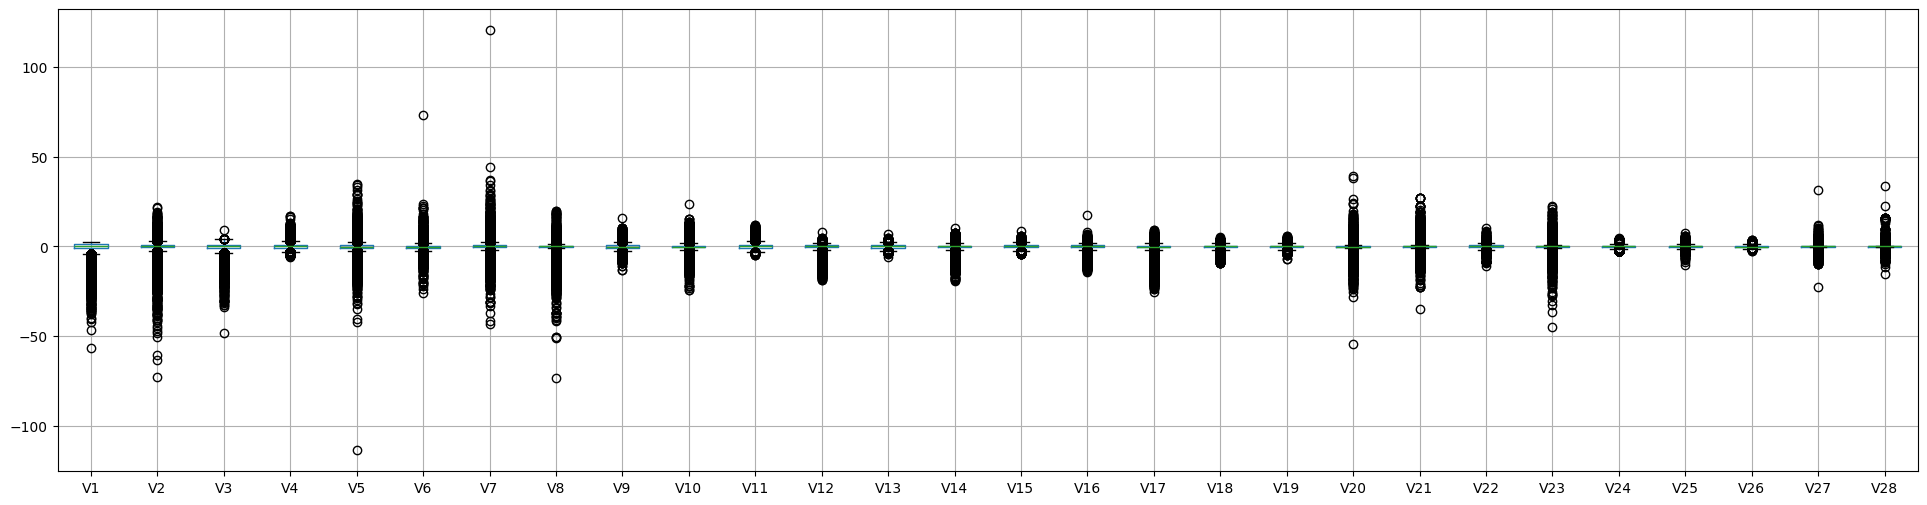

In [3]:
# Create a boxplot on the features column
cols = [f"V{i}" for i in range(1, 29)]

fig, ax = plt.subplots(1, 1, figsize=(24, 6))
fraud_df[cols].boxplot(column=cols, ax=ax)

array([[<Axes: title={'center': 'Amount'}>]], dtype=object)

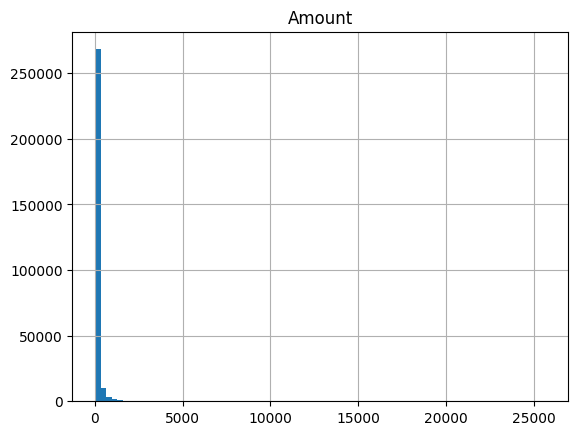

In [4]:
# Create a histogram plot on the Amount column
cols = ["Amount"]
fraud_df[cols].hist(column=cols, bins=80)

In [5]:
# Separate the features and target column
X = fraud_df.drop(columns=["Class"], inplace=False).to_numpy()
y = fraud_df["Class"].to_numpy()

In [6]:
# Create the train, test splits
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
)

In [7]:
# Dataset preprocessing
scaler = StandardScaler()
scaler.fit(X_train, y_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

X_train_normal = X_train[y_train == 0]

X_train_normal.shape

(227451, 30)

In [8]:
def build_model(hp1, input_dim, act="relu"):
    inputs = keras.Input(shape=(input_dim,), name="inputs")

    enc_dec_dim1 = hp1.Choice("enc_dec_dim1", [32, 64, 128, 256, 512])
    enc_dec_dim2 = hp1.Choice("enc_dec_dim2", [32, 64, 128, 256, 512])
    emb_dim = hp1.Choice("embedding_dim", [16, 32, 64, 128])
    dropout = hp1.Float(
        "dropout",
        min_value=3e-1,
        max_value=6e-1,
        step=1e-1,
        sampling="linear",
    )

    x = keras.layers.Dense(enc_dec_dim1, activation=act, name="dense_enc_1")(inputs)
    x = keras.layers.Dropout(dropout)(x)
    x = keras.layers.Dense(enc_dec_dim2, activation=act, name="dense_enc_2")(x)

    b = keras.layers.Dense(emb_dim, activation=act, name="dense_emb")(x)

    d = keras.layers.Dense(enc_dec_dim2, activation=act, name="dense_dec_2")(b)
    d = keras.layers.Dropout(dropout)(d)
    d = keras.layers.Dense(enc_dec_dim1, activation=act, name="dense_dec_1")(d)
    outputs = keras.layers.Dense(input_dim, name="outputs")(d)

    model = keras.Model(inputs, outputs, name="fraud_detection")

    return model

In [9]:
EPOCHS = 100
warmup_epochs = 5

In [10]:
class LearningRateLogger(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs={}):
        optim = self.model.optimizer  # type: ignore
        lr = optim.learning_rate
        if isinstance(lr, keras.optimizers.schedules.LearningRateSchedule):
            lr = lr(optim.iterations)
        logs["learning_rate"] = float(keras.ops.convert_to_numpy(lr))  # type: ignore

In [11]:
size, input_dim = X_train_normal.shape[:2]
batch_size = 64


class Autoencoder(keras_tuner.HyperModel):

    def build(self, hp):
        # Scheduler
        steps_per_epoch = int(np.ceil(size / batch_size))
        total_steps = EPOCHS * steps_per_epoch

        warmup_steps = warmup_epochs * steps_per_epoch

        scheduler = keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=1e-5,
            warmup_target=3e-4,
            warmup_steps=warmup_steps,
            decay_steps=total_steps - warmup_steps,
            alpha=0.01,
        )

        optim_fn = keras.optimizers.Adam(learning_rate=scheduler)  # type: ignore

        model = build_model(hp, input_dim)

        model.compile(
            optimizer=optim_fn,
            loss=keras.losses.MeanSquaredError(),
            metrics=[
                keras.metrics.MeanAbsoluteError(),
                keras.metrics.MeanAbsolutePercentageError(),
            ],
        )

        return model

    def fit(self, hp, model, *args, **kwargs):

        stop_cb = keras.callbacks.EarlyStopping(
            patience=3,
            mode="min",
            restore_best_weights=True,
        )
        lr_cb = LearningRateLogger()

        kwargs["callbacks"].extend([stop_cb, lr_cb])
        kwargs["verbose"] = 0

        with mlflow.start_run():
            mlflow.log_params(hp.values)
            mlflow.tensorflow.autolog(
                log_models=True,
                log_input_examples=True,
                log_model_signatures=True,
                log_every_n_steps=25,
                log_every_epoch=False,
            )
            return model.fit(*args, **kwargs)

In [12]:
tuner = keras_tuner.Hyperband(
    Autoencoder(),
    objective="val_loss",
    max_epochs=EPOCHS,
    directory="../tune",
    project_name="fraud_detection",
)

Reloading Tuner from ../tune/fraud_detection/tuner0.json


In [13]:
tuner.search(
    X_train_normal,
    X_train_normal,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=batch_size,
    verbose=1,
)

best_hp = tuner.get_best_hyperparameters(1)[0]
for k in best_hp.values:
    print(f"{k}: {best_hp.get(k)}")

best_models = tuner.get_best_models(num_models=1)
best_model = best_models[0]

RUTA_MODELO = pathlib.Path(f"../models/reto-05-{best_model.name}.keras")
RUTA_MODELO.parent.mkdir(parents=True, exist_ok=True)

best_model.save(RUTA_MODELO)
print("Modelo guardado en:", RUTA_MODELO.resolve())

enc_dec_dim1: 512
enc_dec_dim2: 512
embedding_dim: 64
dropout: 0.3
tuner/epochs: 100
tuner/initial_epoch: 34
tuner/bracket: 4
tuner/round: 4
tuner/trial_id: 0142
Modelo guardado en: /Users/jmanuelc87/Documents/Projects/bourbaki-track-ciencia-datos/03-deep-learning/models/reto-05-fraud_detection.keras


In [14]:
best_model.summary()

Model: "fraud_detection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inputs (InputLayer)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_enc_1 (Dense)             │ (None, 512)            │        15,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_enc_2 (Dense)             │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_emb (Dense)               │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dec_2 (Dense)             │ (None, 512)            │        33,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_dec_1 (Dense)             │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 30)             │        15,390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 622,686 (2.38 MB)

 Trainable params: 622,686 (2.38 MB)

 Non-trainable params: 0 (0.00 B)

7108/7108 ━━━━━━━━━━━━━━━━━━━━ 4s 491us/step


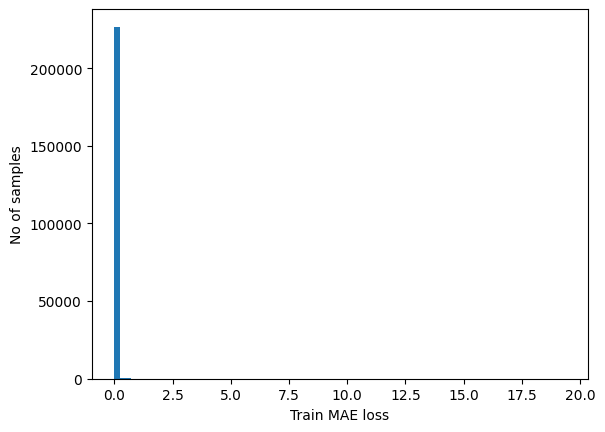

In [30]:
X_train_pred = best_model.predict(X_train_normal)
train_mse_loss = np.mean(np.pow(X_train_pred - X_train_normal, 2), axis=1)

plt.hist(train_mse_loss, bins=80)
plt.xlabel("Train MAE loss")
plt.ylabel("No of samples")
plt.show()

In [31]:
X_test_pred = best_model.predict(X_test)
reconstruction_error = np.mean(np.pow(X_test - X_test_pred, 2), axis=1)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 1s 488us/step


In [32]:
fpr, tpr, roc_thresholds = roc_curve(y_test, reconstruction_error)
precision, recall, pr_thresholds = precision_recall_curve(y_test, reconstruction_error)

auc_roc = roc_auc_score(y_test, reconstruction_error)
auc_pr = average_precision_score(y_test, reconstruction_error)

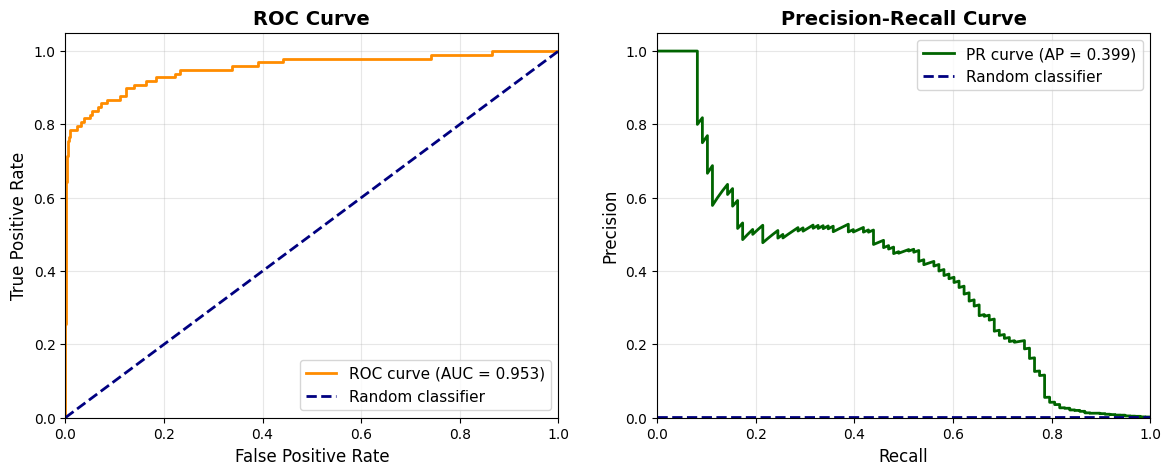

In [38]:
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: ROC Curve
axes[0].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {auc_roc:.3f})"
)
axes[0].plot(
    [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random classifier"
)
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate", fontsize=12)
axes[0].set_ylabel("True Positive Rate", fontsize=12)
axes[0].set_title("ROC Curve", fontsize=14, fontweight="bold")
axes[0].legend(loc="lower right", fontsize=11)
axes[0].grid(alpha=0.3)

# Plot 2: Precision-Recall Curve
axes[1].plot(
    recall, precision, color="darkgreen", lw=2, label=f"PR curve (AP = {auc_pr:.3f})"
)
axes[1].axhline(
    y=sum(y_test) / len(y_test),
    color="navy",
    lw=2,
    linestyle="--",
    label="Random classifier",
)
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("Recall", fontsize=12)
axes[1].set_ylabel("Precision", fontsize=12)
axes[1].set_title("Precision-Recall Curve", fontsize=14, fontweight="bold")
axes[1].legend(loc="upper right", fontsize=11)
axes[1].grid(alpha=0.3)

In [49]:
# --- Summary metrics ---
print("Autoencoder – Reconstruction Error as Anomaly Score")
print(f"Test samples:           {len(y_test):,}")
print(
    f"Fraud cases (positive): {int(np.sum(y_test)):,} "
    f"({np.mean(y_test) * 100:.3f}%)"
)
print(f"AUC-ROC:                {auc_roc:.4f}")
print(f"AUC-PR (Avg Precision): {auc_pr:.4f}")
print(f"PR baseline (random):   {np.mean(y_test):.4f}")
print(f"AUC-PR lift vs random:  {auc_pr / np.mean(y_test):.1f}x")
print(f"ROC thresholds evaluated: {len(roc_thresholds):,}")
print(f"PR thresholds evaluated:  {len(pr_thresholds):,}")


# --- Best AUC ROC threshold ---
# Calculate Youden Index
youden_index = tpr - fpr - 1

# Find the threshold that maximizes Youden Index
optimal_idx = np.argmax(youden_index)
optimal_threshold = roc_thresholds[optimal_idx]

print(f"Optimal Threshold: {optimal_threshold:.4f}")
print(f"TPR at optimal threshold: {tpr[optimal_idx]:.4f}")
print(f"FPR at optimal threshold: {fpr[optimal_idx]:.4f}")


# --- Best PR threshold (max F1) ---
# precision/recall have one more element than pr_thresholds
f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)

# Get the index of the best precision
f1_idx = np.argmax(f1_scores)
optimal_pr_threshold = pr_thresholds[f1_idx]

print("Best threshold by F1 (Precision-Recall):")
print(f"  Threshold: {pr_thresholds[f1_idx]:.6f}")
print(f"  Precision: {precision[f1_idx]:.4f}")
print(f"  Recall:    {recall[f1_idx]:.4f}")
print(f"  F1-score:  {f1_scores[f1_idx]:.4f}")

Autoencoder – Reconstruction Error as Anomaly Score
Test samples:           56,962
Fraud cases (positive): 98 (0.172%)
AUC-ROC:                0.9530
AUC-PR (Avg Precision): 0.3988
PR baseline (random):   0.0017
AUC-PR lift vs random:  231.8x
ROC thresholds evaluated: 240
PR thresholds evaluated:  56,905
Optimal Threshold: 0.0233
TPR at optimal threshold: 0.8571
FPR at optimal threshold: 0.0722
Best threshold by F1 (Precision-Recall):
  Threshold: 0.543463
  Precision: 0.4561
  Recall:    0.5306
  F1-score:  0.4906


              precision    recall  f1-score   support

           0       1.00      0.93      0.96     56864
           1       0.02      0.85      0.04        98

    accuracy                           0.93     56962
   macro avg       0.51      0.89      0.50     56962
weighted avg       1.00      0.93      0.96     56962



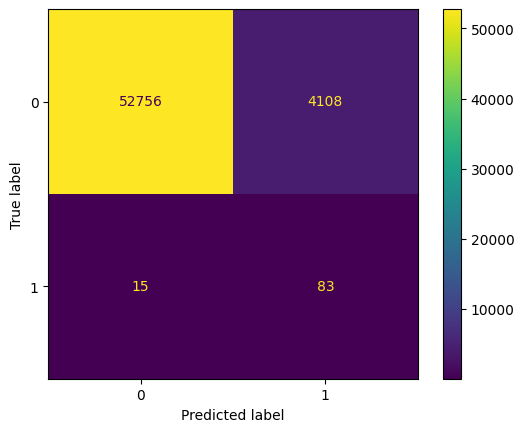

In [54]:
y_pred = (reconstruction_error > optimal_threshold).astype(int)
print(classification_report(y_test, y_pred))
ma = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(ma).plot()

En la matriz de confusión mencionada arriba la detección de Verdaderos Positivos (TP) es más alta pero tambien un mayor número de casos Falsos Positivos (FP) lo que aumenta la cantidad de trabajo manual y el costo de revisar cada caso.

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.07      0.79      0.14        98

    accuracy                           0.98     56962
   macro avg       0.54      0.88      0.56     56962
weighted avg       1.00      0.98      0.99     56962



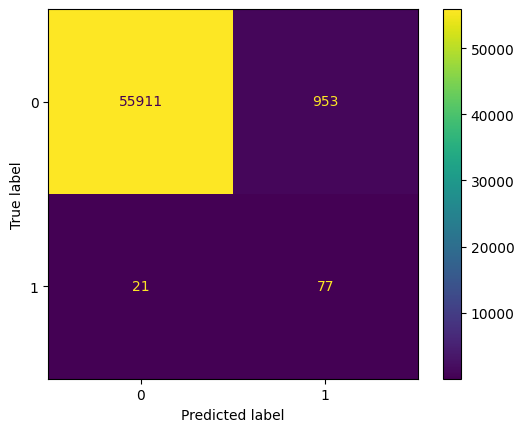

In [55]:
y_pred = (reconstruction_error > fpr[optimal_idx]).astype(int)
print(classification_report(y_test, y_pred))
ma = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(ma).plot()

En la matriz de confusión mencionada en esta parte la detección de Verdaderos Positivos (TP) es menor pero también es mucho menor el número de casos Falsos Positivos (FP) por lo que disminuye la cantidad de trabajo manual y costo para revisar cada caso en gran medida

Por otro lado la cantidad de Falsos Negativos (FN) es menor en el primer modelo lo que sugiere que se escapan menos fraudes mal clasificados que en el segundo modelo que aumenta la cantidad de mal classificados por lo que es mayor la probabilidad de un fraude se clasifique como falso cuando es verdadero.